# Obtención de la señal

In [1]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 46.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.


In [2]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal



In [3]:
# Obtener la lista de todos los registros disponibles en la base de datos MIT-BIH
record_list = wfdb.get_record_list('mitdb')

print(f"Número total de registros en la base de datos MIT-BIH: {len(record_list)}")
max = record_list [len(record_list)-1]
min = record_list [0]
print (record_list)

print ('El valor minimo y maximo es ', min , ' y ', max, ' respectivamente.')
#print("Primeros 10 registros:")
#for i, record_name in enumerate(record_list[:10]):
 #   print(f"- {record_name}")

Número total de registros en la base de datos MIT-BIH: 48
['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']
El valor minimo y maximo es  100  y  234  respectivamente.


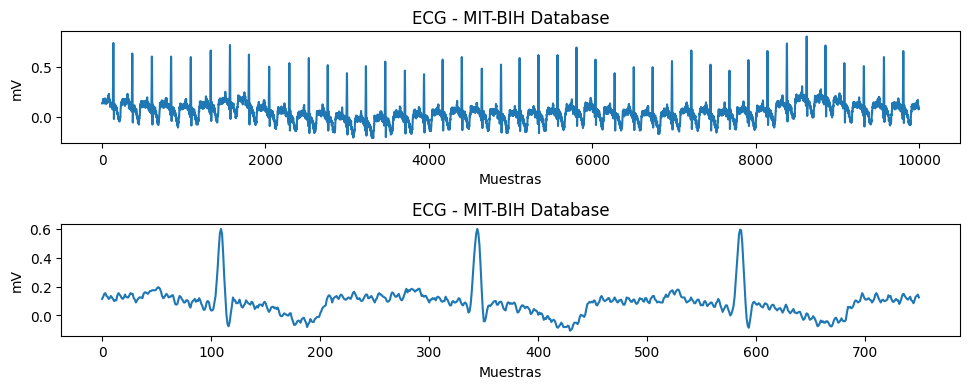

In [4]:
record = wfdb.rdrecord('234', pn_dir= 'mitdb' )
signal = record.p_signal [: , 1]

plt.figure(figsize=(10, 4))
plt.subplot(2, 1, 1)
plt.plot(signal[:10000]) # Grafica los primeros 10000 puntos
plt.title("ECG - MIT-BIH Database")
plt.xlabel("Muestras")
plt.ylabel("mV")

#Zoom
plt.subplot(2, 1, 2)
plt.plot(signal[500:1250])
plt.title("ECG - MIT-BIH Database")
plt.xlabel("Muestras")
plt.ylabel("mV")

plt.tight_layout()
plt.show()

In [5]:
Fr_Muestreo = record.fs
Fr_Nyquist = Fr_Muestreo/2
P_muestreo = 1/Fr_Muestreo

print ('Fr_Muestreo es ', Fr_Muestreo, ' y P_muestreo es ', P_muestreo)
print('La Fr_Nyquist es ', Fr_Nyquist)

Fr_Muestreo es  360  y P_muestreo es  0.002777777777777778
La Fr_Nyquist es  180.0


# 1. Preprocesamiento Híbrido (Fourier + Wavelet)


**Filtro Notch (Fourier):** Se aplica primero para eliminar específicamente los 50 o 60 Hz de la red eléctrica. Es imbatible en esta tarea específica.

**Denoising Wavelet (db4 o sym4):** Se usa para limpiar el ruido muscular (EMG) y la deriva de la línea base. A diferencia del filtro pasa-altos tradicional, la Wavelet permite quitar el movimiento del paciente sin deformar el segmento ST, que es vital para detectar infartos.

# Análisis con Fourier

<function matplotlib.pyplot.show(close=None, block=None)>

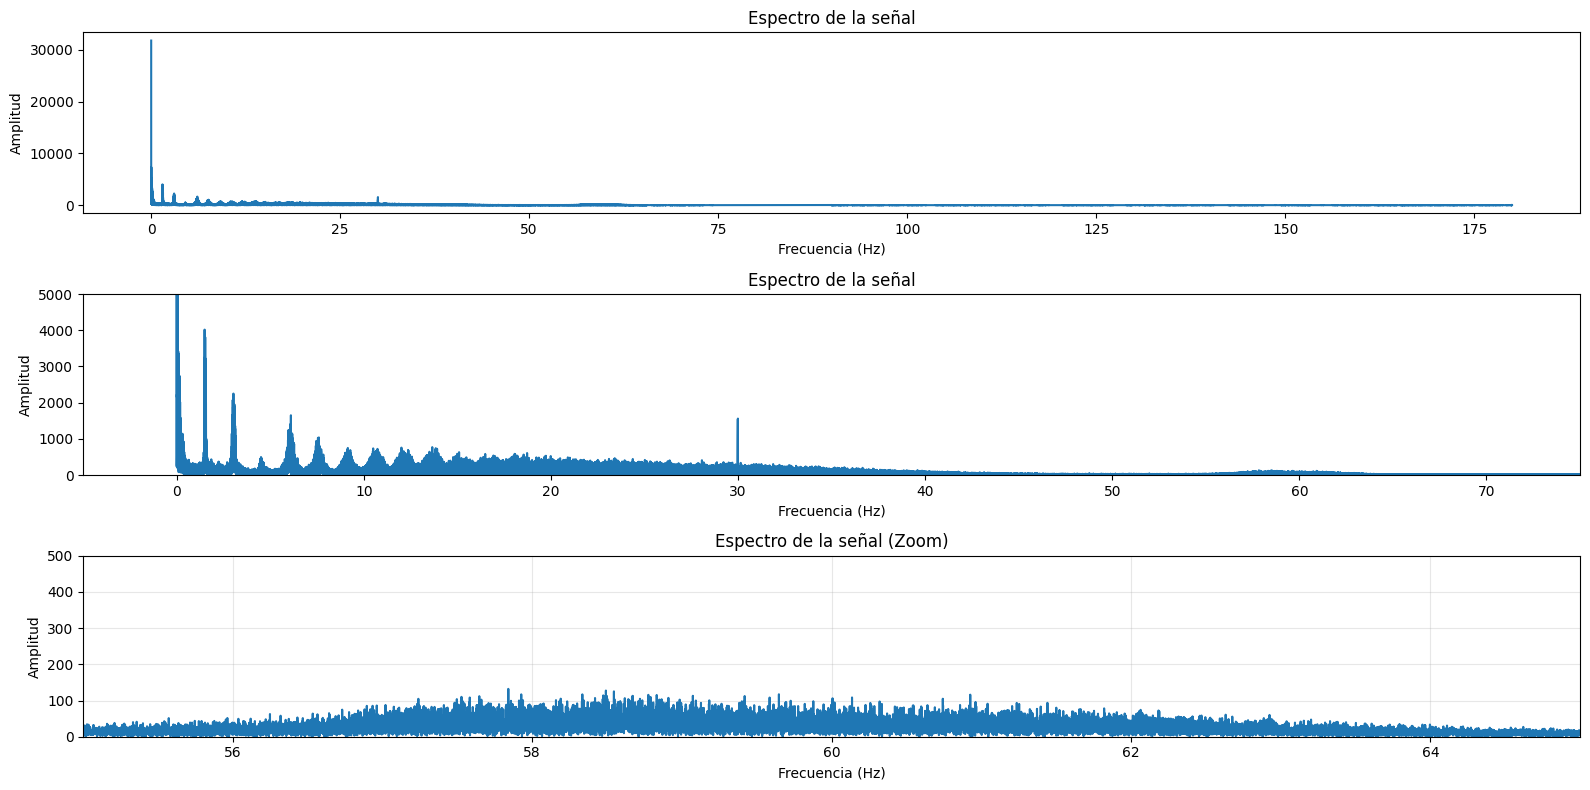

In [6]:
fs = Fr_Muestreo

#App la TF (usamos rfft porque nuestra señal es real)
n =  len (signal)
frecuencias = np.fft.rfftfreq(n, 1/fs)
espectro = np.abs (np.fft.rfft(signal))

plt.figure(figsize=(16, 8))

plt.subplot(3, 1, 1)
plt.plot(frecuencias, espectro)
plt.title("Espectro de la señal")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")


#ZOOM
plt.subplot(3, 1, 2)
plt.plot(frecuencias,espectro)
plt.xlim(-5,75)
plt.ylim(0,5000)
plt.title("Espectro de la señal")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")

#ZOOM para ver los armonicos
plt.subplot(3, 1, 3)
plt.plot(frecuencias,espectro)
plt.xlim(55,65)
plt.ylim(0,500)
plt.title("Espectro de la señal (Zoom)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")

plt.grid (True, alpha = 0.3)
plt.tight_layout()
plt.show

1. Se observa la pared inicial producto del nivel de corriente continua y del movimiento de linea de base
2. De 0,5-45Hz debería estar contenida la información médica.
3. En 50/60 Hz no se observa picos, sino que en 60Hz solo un leve relieve producto de interferencia de los cables .


Habría que introducir un filtro pasa altos, para reducir los picos iniciales. Además de observar el pico producido en 30Hz

# ***Conclusion de Fourier:***
No existe un pico abrupto en 50/60Hz indicando la presencia de interferencia de red. Por lo que no es necesario aplicar notch, en la que es especialista la TF.

El restante de los filtros (PA - PB) serán aplicados mediante la wavelet.

# Análisis con Wavelet

**Configuración de la DWT (Descomposición)**


Como busco primero eliminar la Deriva Basal (Respiración), se toman 9 niveles para aproximarme a los 0.5Hz.

En la imagen se muestra el contenido en frecuencia de cada nivel

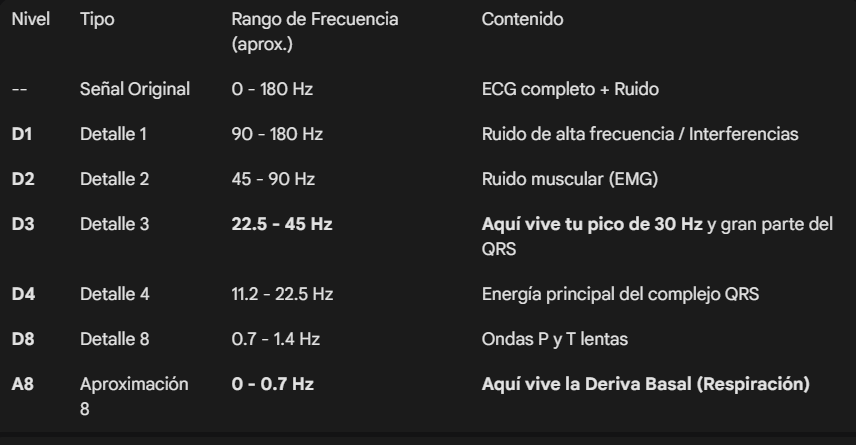

# Paso A: Eliminar la Deriva Basal (Pasa-altos)


Al descomponer hasta el nivel 8, la aproximación final ($cA_9$) contiene todo lo que sea más lento que 0.7 Hz. Al poner esto en cero, se elimina el "sube y baja" de la señal de forma mucho más limpia que con un filtro analógico.


En lugar de usar un filtro Butterworth que puede deformar el segmento ST,  se elimina simplemente el nivel más alto de Aproximación (cA_n).
      Ejemplo: Si se descompone a 9 niveles, el cA_9 contiene las frecuencias de 0 a 0.5 Hz (la respiración). Al poner ese nivel a cero antes de reconstruir, se hecho un filtro pasa-altos perfecto sin desfase.


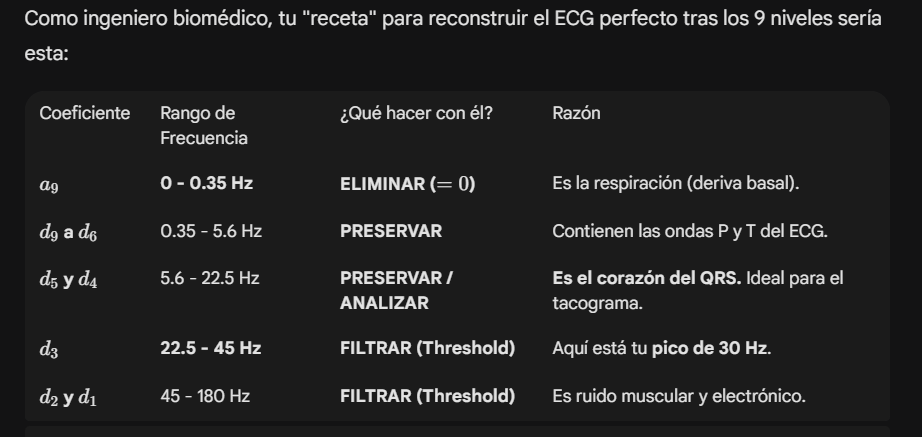

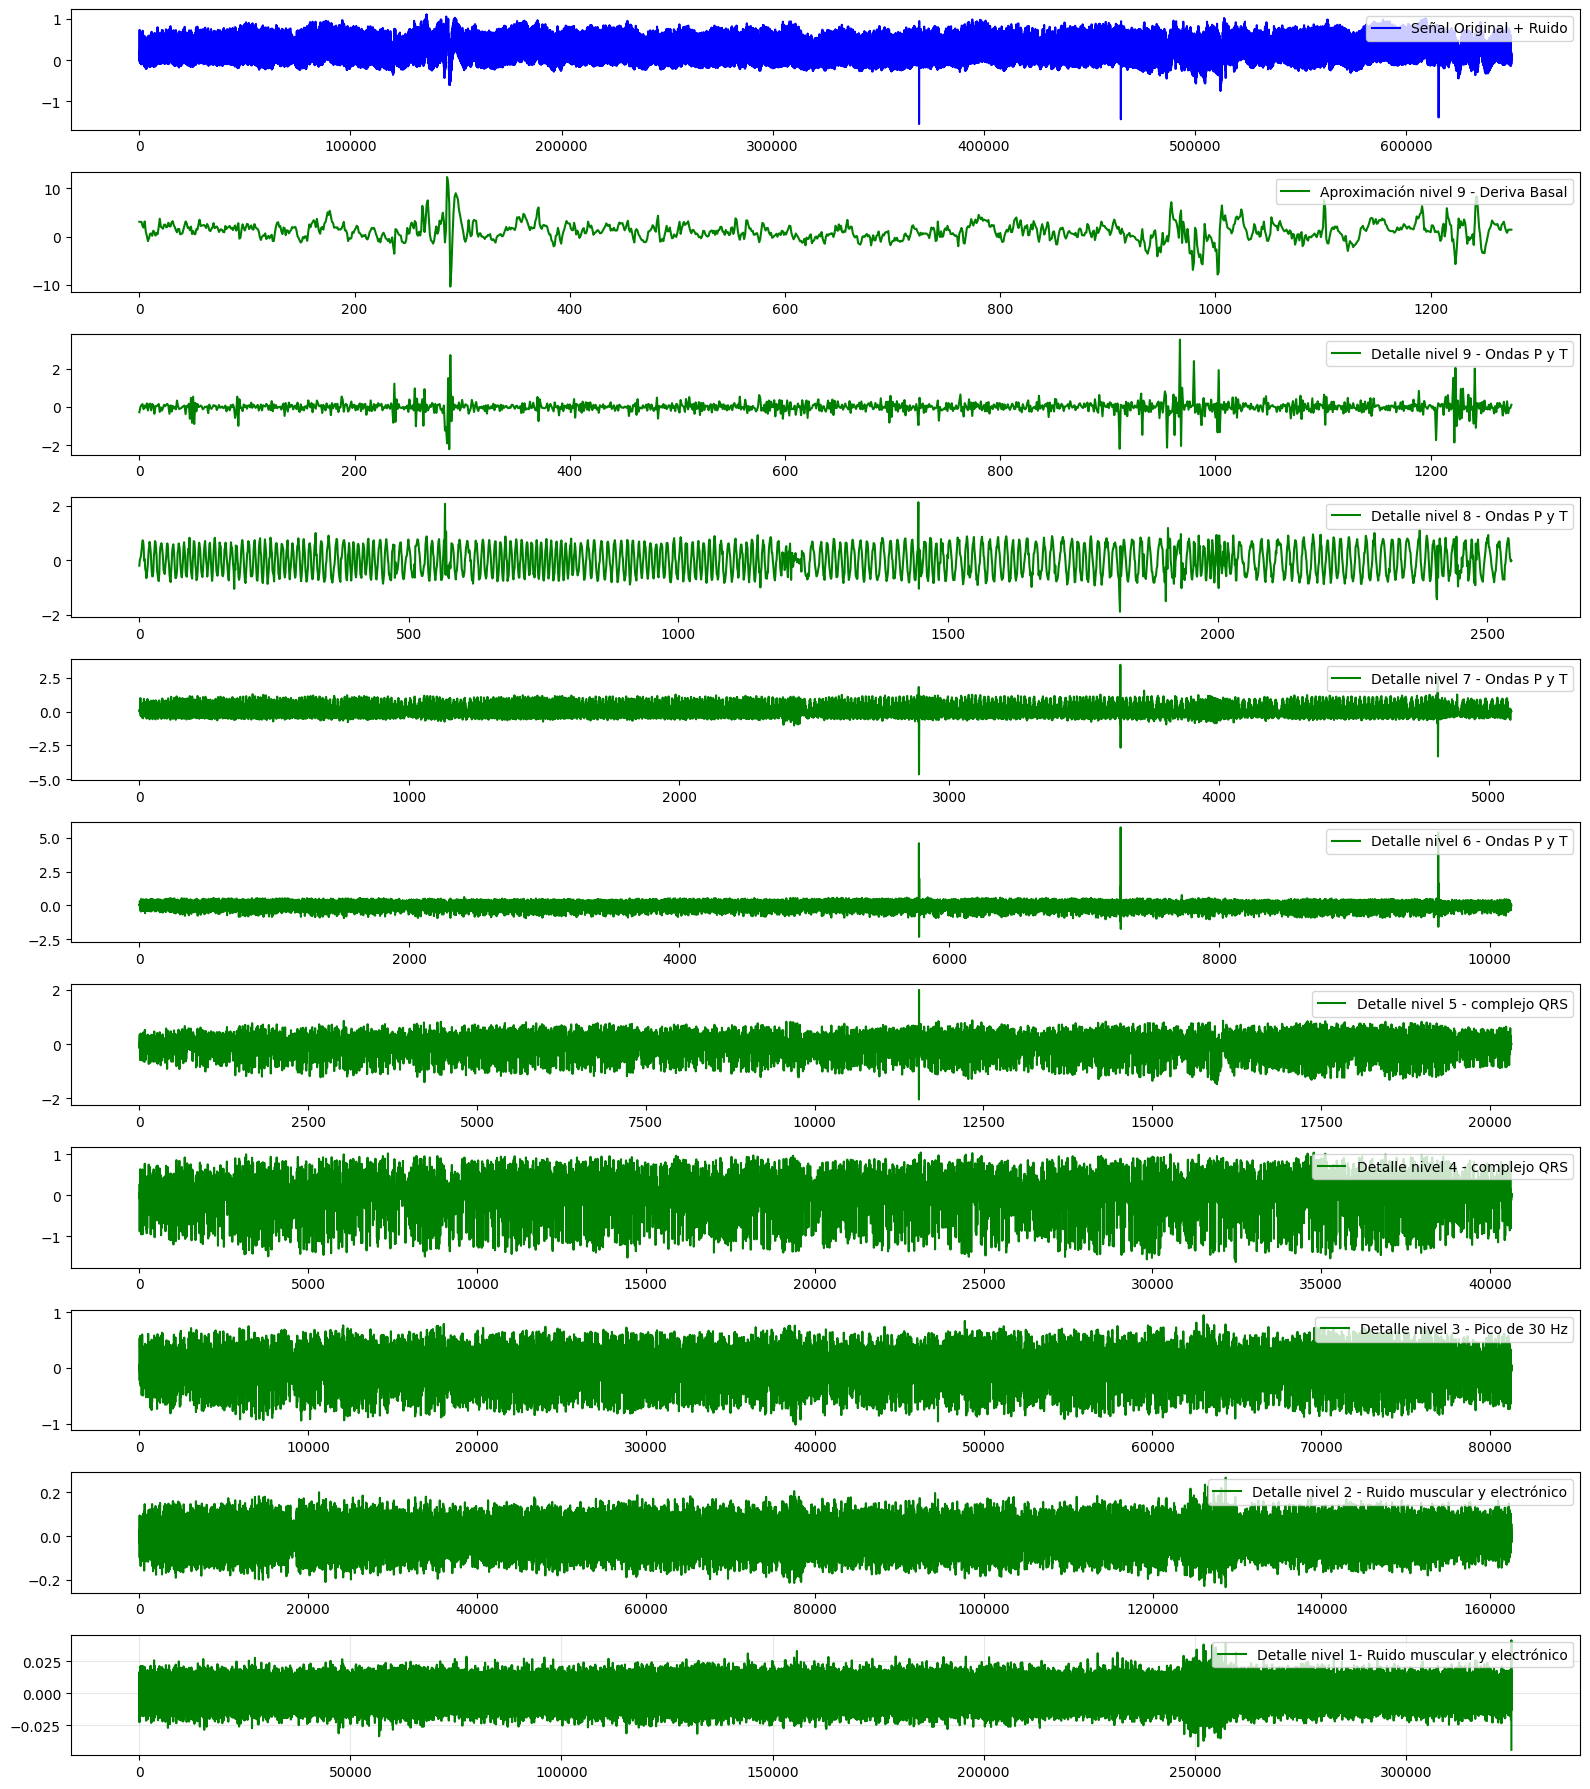

In [7]:
#Para obtener los coeficientes de la descomposición en aproximación y detalles
#de una señal usando una ondita determinada, se usa el comando wavedec:
#tenemos la descomposición en 9 pasos/niveles:

import pywt


[a9, d9, d8,d7,d6,d5, d4,d3, d2, d1 ] = pywt.wavedec (signal, 'sym4', level = 9)

#Observar que la cant. de muestras de los niveles aumentan  multiplicándose por 2 (aprox)

plt.figure(figsize=(16,18))
plt.subplot(11, 1, 1)
plt.plot(signal, color='blue', label='Señal Original + Ruido')
plt.legend(loc='upper right')

plt.subplot(11, 1, 2)
plt.plot(a9, color='green', label='Aproximación nivel 9 - Deriva Basal')
plt.legend(loc='upper right')

plt.subplot(11, 1, 3)
plt.plot(d9, color='green', label='Detalle nivel 9 - Ondas P y T')
plt.legend(loc='upper right')
plt.subplot(11, 1, 4)
plt.plot(d8, color='green', label='Detalle nivel 8 - Ondas P y T')
plt.legend(loc='upper right')

plt.subplot(11, 1, 5)
plt.plot(d7, color='green', label='Detalle nivel 7 - Ondas P y T')
plt.legend(loc='upper right')
plt.subplot(11, 1, 6)
plt.plot(d6, color='green', label='Detalle nivel 6 - Ondas P y T')
plt.legend(loc='upper right')

plt.subplot(11, 1, 7)
plt.plot(d5, color='green', label='Detalle nivel 5 - complejo QRS')
plt.legend(loc='upper right')
plt.subplot(11, 1, 8)
plt.plot(d4, color='green', label='Detalle nivel 4 - complejo QRS')
plt.legend(loc='upper right')

plt.subplot(11, 1, 9)
plt.plot(d3, color='green', label='Detalle nivel 3 - Pico de 30 Hz')
plt.legend(loc='upper right')
plt.subplot(11, 1, 10)
plt.plot(d2, color='green', label='Detalle nivel 2 - Ruido muscular y electrónico')
plt.legend(loc='upper right')
# The next plot would be outside the 10x1 grid if d1 is also plotted.
# I'm commenting it out for now to avoid an error.
# If you need to plot d1 as well, consider increasing the number of rows
# or adjusting the layout.
plt.subplot(11, 1, 11)
plt.plot(d1, color='green', label='Detalle nivel 1- Ruido muscular y electrónico')
plt.legend(loc='upper right')

plt.tight_layout()
plt.grid (True, alpha = 0.3)
plt.show()

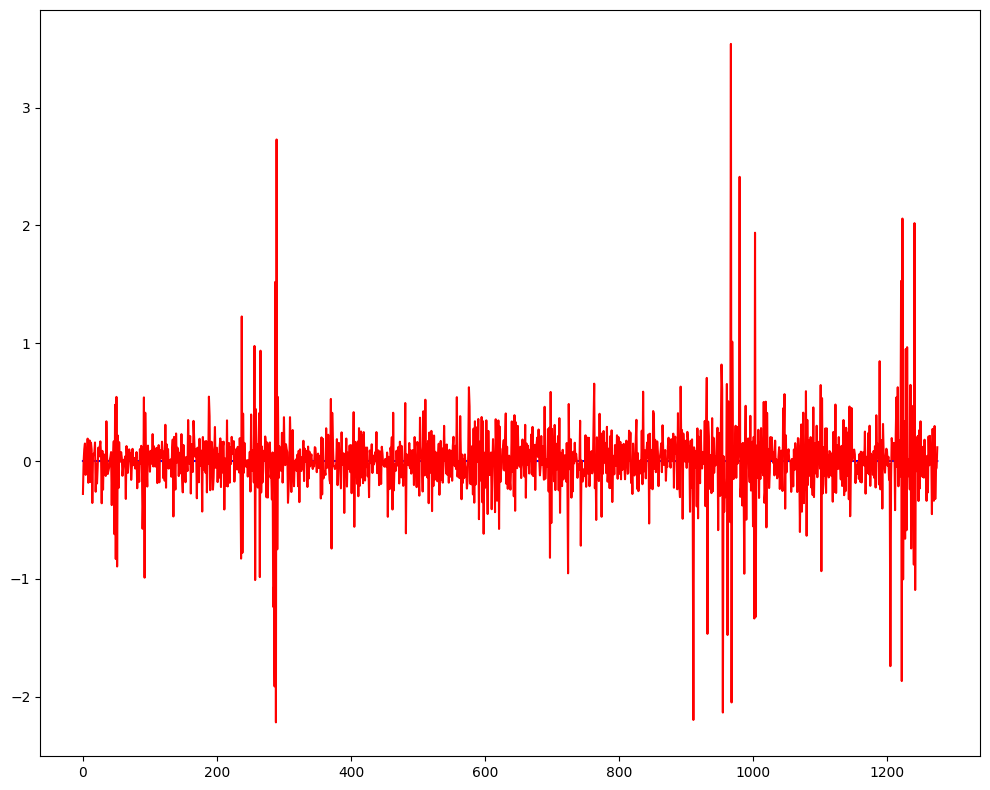

In [8]:
#Eliminamos finalmente el filtro basal
# 1. Crear una copia de los coeficientes para no alterar los originales
coeffs_filtrados = [a9, d9, d8, d7, d6, d5, d4, d3, d2, d1]

# 2. "Extirpación": Ponemos la aproximación 9 a cero (adiós respiración)
coeffs_filtrados[0] = np.zeros_like(a9)
a9_filtrada = coeffs_filtrados[0]

plt.figure (figsize =(10,8))
plt.plot (a9_filtrada, color = 'b')
plt.plot (d9, color = 'r')
plt.tight_layout ()
plt.show()

SE observa la correcta eliminación de la deriva basal. Queda solo la señal que contiene info médica, siendo estable en el tiempo y en amplitud.

# Paso B: Limpiar el pico de 30 Hz
Como se vio, los 30 Hz caen en el nivel de Detalle 3 ($cD_3$).

Por tanto, no se borra el nivel 3 por completo (porque ahí también hay información del latido), sino que se aplica un Soft Thresholding. Esto "limpia" el ruido constante de 30 Hz y deja pasar los picos R que son mucho más intensos.

In [15]:
import pywt

def aplicar_umbral_biomedico(coeficiente):
    """
    Aplica el umbral universal de Donoho con estimación robusta (MAD).
    """
    # 1. Estimación robusta de la desviación estándar del ruido (sigma)
    sigma = np.median(np.abs(coeficiente)) / 0.6745

    # 2. Cálculo del Umbral Universal (T)
    # n es la longitud del vector de coeficientes
    n = len(coeficiente)
    T = sigma * np.sqrt(2 * np.log(n))

    # 3. Aplicación de la Umbralización Suave
    return pywt.threshold(coeficiente, value=T, mode='soft')

# Aplicación quirúrgica a los niveles de ruido identificados:
d3_filtrado = aplicar_umbral_biomedico(d3) # Limpia el pico de 30 Hz
d2_filtrado = aplicar_umbral_biomedico(d2) # Limpia ruido muscular/electrónico
d1_filtrado = aplicar_umbral_biomedico(d1) # Limpia ruido de alta frecuencia



## Conceptos Clave Aplicados:
- Estimación MAD (Median Absolute Deviation): Se usa $\sigma = \frac{\text{mediana}(|d_j|)}{0.6745}$ porque es insensible a los picos altos del ECG (los complejos QRS), permitiendo medir el ruido de fondo sin "contaminarse" por el latido.

- Umbral Universal ($T$): Calculado como $T = \sigma \sqrt{2 \ln(n)}$. Es el estándar para eliminar ruido gaussiano blanco en señales de banda ancha.

- Modo 'soft': Reduce los coeficientes hacia cero en lugar de cortarlos abruptamente, lo que evita la aparición de artefactos o "picos fantasmas" en la reconstrucción final del ECG.

# IDWT (Reconstrucción): ECG clínico definitivo.

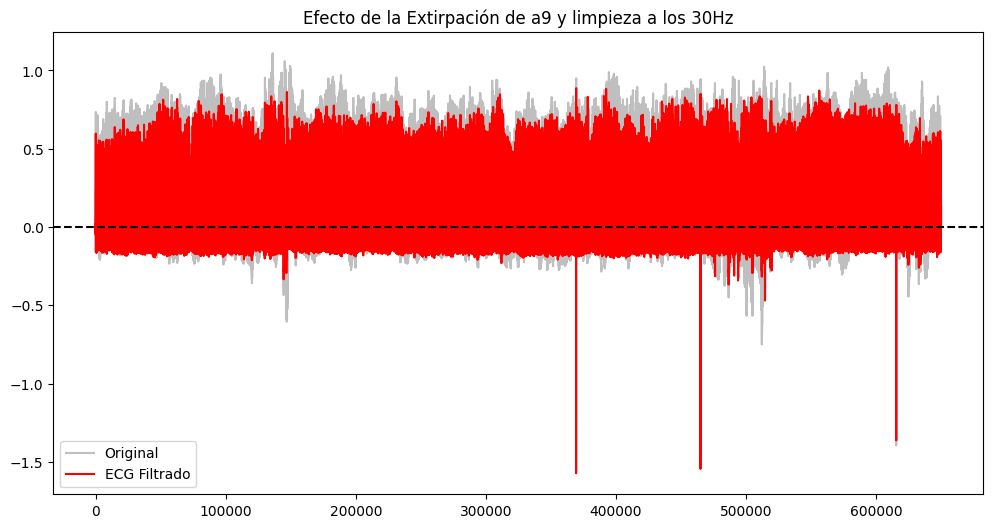

In [10]:
# 4. ENSAMBLE FINAL
# Mantenemos d9 a d4 intactos para preservar las ondas P, T y el complejo QRS
coeffs_filtrados = [a9_filtrada, d9, d8, d7, d6, d5, d4, d3_filtrado,d2_filtrado, d1_filtrado]

# 5. RECONSTRUCCIÓN (IDWT)
signal_limpia = pywt.waverec(coeffs_filtrados, 'sym4')

plt.figure(figsize=(12, 6))
plt.plot(signal, alpha=0.5, label='Original', color='gray')
plt.plot(signal_limpia, label='ECG Filtrado', color='red', lw=1.5)
plt.axhline(0, color='black', linestyle='--')
plt.title("Efecto de la Extirpación de a9 y limpieza a los 30Hz")
plt.legend()
plt.show()


plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

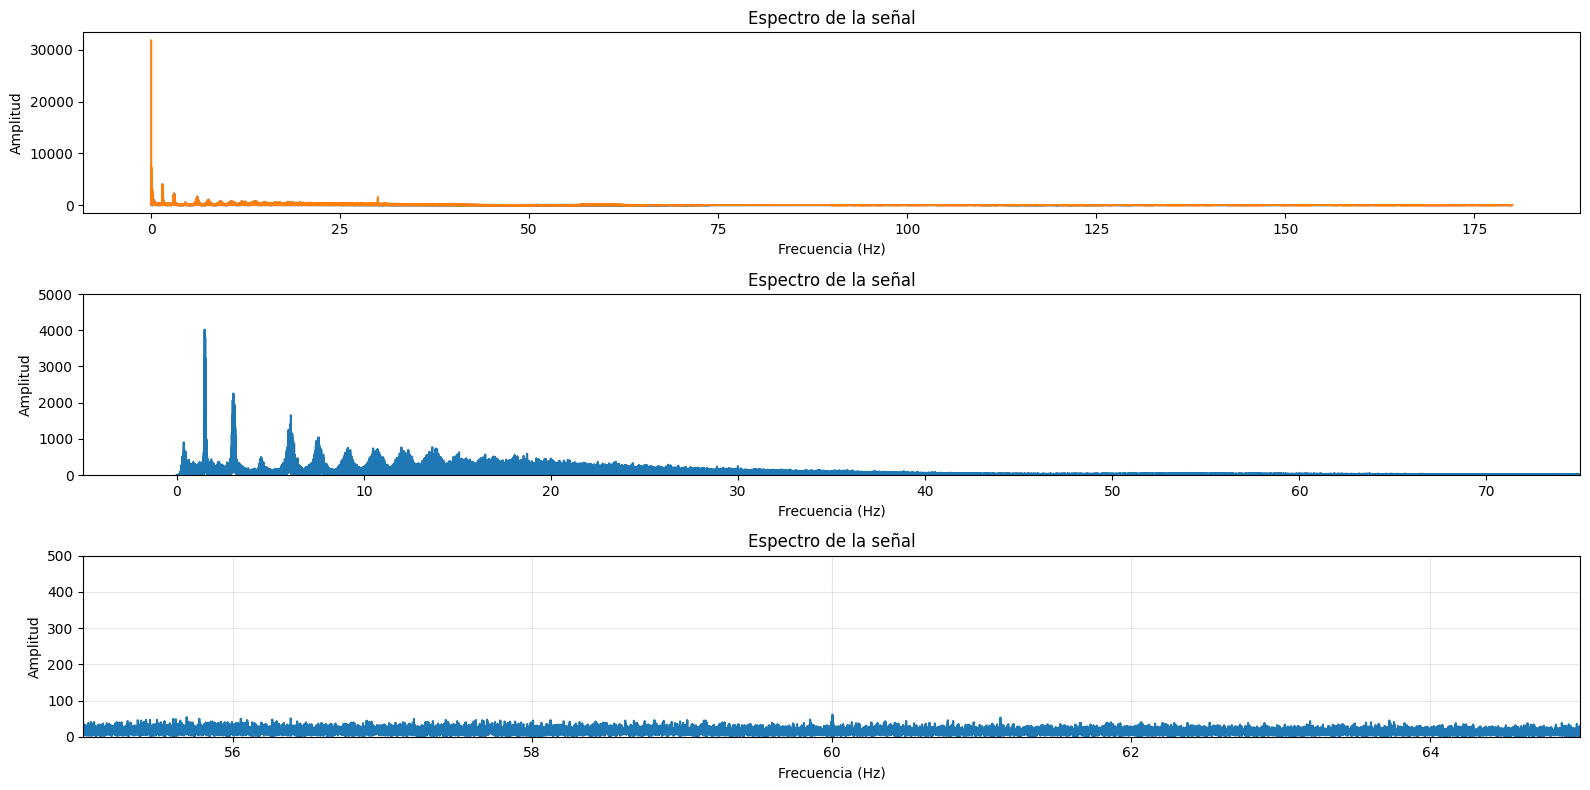

In [11]:
fs = Fr_Muestreo

#App la TF (usamos rfft porque nuestra señal es real)
n1 =  len (signal_limpia)
frecuencias1 = np.fft.rfftfreq(n1, 1/fs)
espectro1 = np.abs (np.fft.rfft(signal_limpia))

plt.figure(figsize=(16, 8))

plt.subplot(3, 1, 1)
plt.plot(frecuencias1, espectro1)
plt.plot(frecuencias, espectro)
plt.title("Espectro de la señal")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")


#ZOOM
plt.subplot(3, 1, 2)
plt.plot(frecuencias1,espectro1)
plt.xlim(-5,75)
plt.ylim(0,5000)
plt.title("Espectro de la señal")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")

#ZOOM para ver los armonicos
plt.subplot(3, 1, 3)
plt.plot(frecuencias1,espectro1)
plt.xlim(55,65)
plt.ylim(0,500)
plt.title("Espectro de la señal")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")

plt.grid (True, alpha = 0.3)
plt.tight_layout()
plt.show

1. El éxito en la frecuencia 0 Hz (Deriva Basal)
Si se observa el segundo gráfico de la última imagen (image_a40de6.png), se ve que el eje vertical en 0 Hz ya no tiene ese pico masivo que "ahogaba" al resto.

*Diagnóstico:* Al haber hecho $a_9 = 0$, se elimina la componente de corriente continua (DC) y la respiración.

*Resultado:* Esto es lo que permite que la señal en el tiempo (la gráfica roja de image_a4069d.png) esté perfectamente centrada.


2. El pico de 30 HzEn el mismo gráfico (zoom de 0 a 75 Hz), si se mira la marca de los 30 Hz, se notara que la amplitud es ahora muy pequeña en comparación con los picos del ECG (que están entre 1 y 15 Hz).

*Diagnóstico: *La umbralización en $d_3$ funcionó. No se borró el latido, pero se "aplanó" esa interferencia constante que tenías antes.

3. ¿Qué son esos picos que quedaron?
Es normal (y necesario) ver picos entre 1 Hz y 20 Hz, puesto que:

- Pico en ~1.2 Hz: Es la frecuencia cardíaca básica (aprox. 72 latidos por minuto).

- Picos sucesivos: Son los armónicos de la forma de onda del ECG (el complejo QRS no es una sinusoide pura, por eso genera varios picos en el espectro).

# Detección de Picos R

--- RESULTADOS ---
Total de latidos detectados: 2741
Ritmo cardíaco promedio: 91.21 BPM


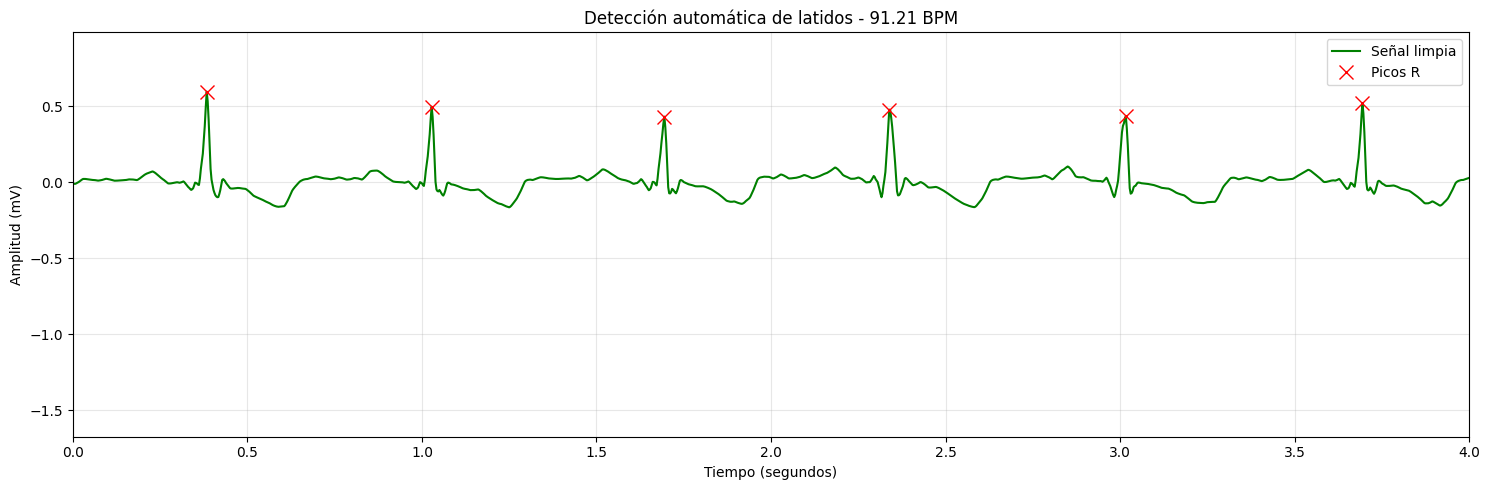

In [16]:
from scipy.signal import find_peaks

# 1. Ajuste de parámetros (CORREGIDO)
# Usamos el 50% del valor máximo de tu señal para que sea adaptativo
altura_minima = np.percentile(signal_limpia, 95) * 0.6

# Distancia mínima basada en fisiología (0.5 segundos * 360 Hz)
# Esto evita detectar la onda T como un latido
distancia_minima = int(0.5 * fs)

# 2. Búsqueda de índices (CORREGIDO con nombres de argumentos)
picos, _ = find_peaks(signal_limpia, height=altura_minima, distance=distancia_minima)

# 3. Calculamos el tiempo entre latidos (Esto estaba muy bien)
intervalos_rr = np.diff(picos) / fs
bpm_instantes = 60 / intervalos_rr
bpm_promedio = np.mean(bpm_instantes)

print(f"--- RESULTADOS ---")
print(f"Total de latidos detectados: {len(picos)}")
print(f"Ritmo cardíaco promedio: {bpm_promedio:.2f} BPM")

# 4. Visualización con Zoom
plt.figure(figsize=(15, 5))
tiempo = np.arange(len(signal_limpia)) / fs

plt.plot(tiempo, signal_limpia, color='g', label='Señal limpia', linewidth=1.5)
plt.plot(tiempo[picos], signal_limpia[picos], 'x', color='r', label='Picos R', markersize=10)

plt.title(f'Detección automática de latidos - {bpm_promedio:.2f} BPM')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Amplitud (mV)')
plt.xlim(0, 4)
plt.ylim(np.min(signal_limpia)-0.1, np.max(signal_limpia)+0.1)

plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tacograma

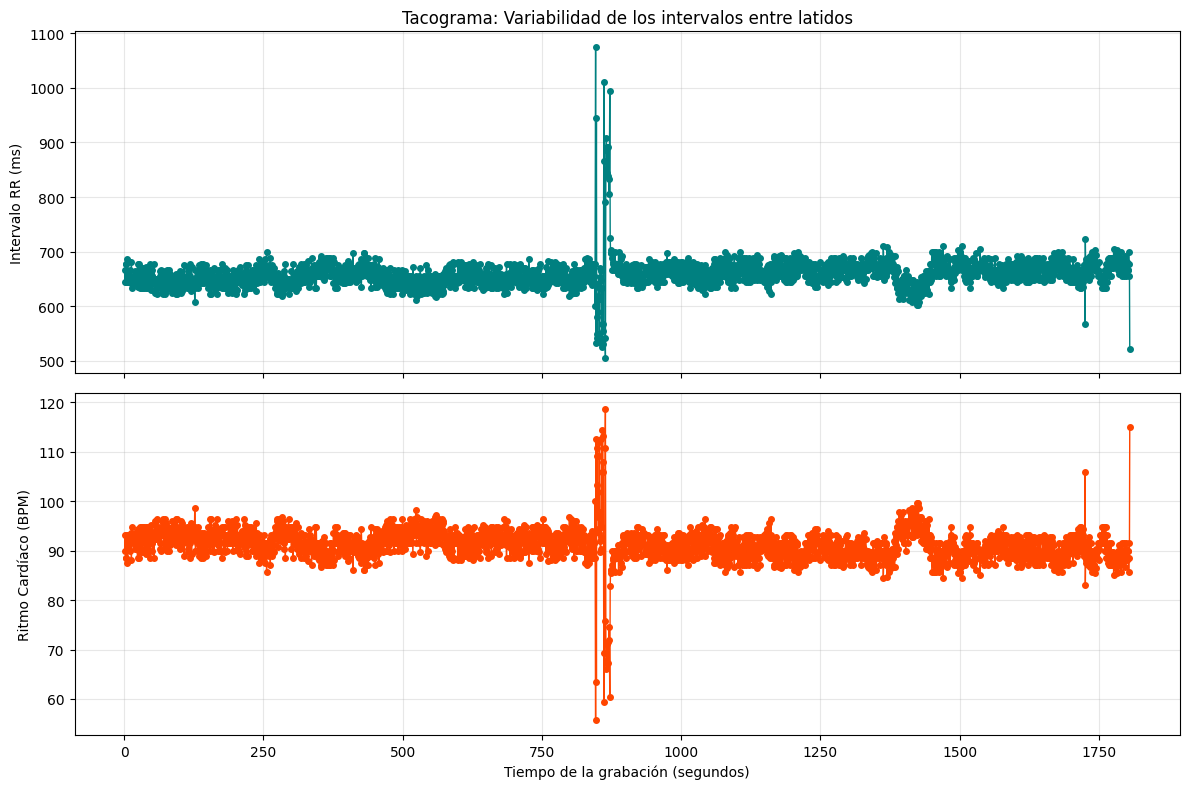

In [17]:
# 1. Calculamos los tiempos exactos de cada latido (en segundos)
tiempos_latidos = picos / fs

# 2. Calculamos los intervalos RR en milisegundos (ms)
# Es la diferencia entre un pico y el anterior
intervalos_rr_ms = np.diff(tiempos_latidos) * 1000

# 3. Calculamos el BPM instantáneo para cada par de latidos
bpm_instantaneo = 60 / (np.diff(tiempos_latidos))

# --- Visualización ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Gráfica 1: Intervalos RR (ms)
# Usamos el tiempo del segundo latido de cada par para el eje X
ax1.plot(tiempos_latidos[1:], intervalos_rr_ms, 'o-', color='teal', markersize=4, linewidth=1)
ax1.set_ylabel("Intervalo RR (ms)")
ax1.set_title("Tacograma: Variabilidad de los intervalos entre latidos")
ax1.grid(True, alpha=0.3)

# Gráfica 2: Frecuencia Cardíaca Instantánea (BPM)
ax2.plot(tiempos_latidos[1:], bpm_instantaneo, 'o-', color='orangered', markersize=4, linewidth=1)
ax2.set_ylabel("Ritmo Cardíaco (BPM)")
ax2.set_xlabel("Tiempo de la grabación (segundos)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1. Estabilidad del Ritmo:

 El Tacograma muestra una banda muy sólida y horizontal durante los 1800 segundos (30 minutos). Esto indica un ritmo sinusal estable, sin arritmias graves evidentes.

2. Valores de Referencia:

 El promedio de 658.78 ms (~91 BPM) sitúa al paciente en un estado de taquicardia leve. Es un ritmo alto para alguien en reposo total, lo que explicaría por qué la variabilidad es baja.

3. Variabilidad (SDNN):

El dato objetivo de SDNN = 26.72 ms indica una HRV baja. Un corazón "muy rítmico" (como un metrónomo) a veces es señal de que el sistema nervioso está bajo estrés o fatiga.


4. Análisis del Artefacto (El "Pico" a los 850 segundos)

Hay un evento muy notable cerca del segundo 850. Allí se observa un salto brusco hacia los 1100 ms seguido de una caída a los 500 ms.

Causa técnica: Es casi seguro un artefacto de movimiento. Probablemente el paciente se movió, el electrodo perdió contacto momentáneamente y el algoritmo:

a) Se saltó un latido (haciendo que el intervalo RR parezca el doble: ~1100 ms).

b) Detectó un ruido como latido (haciendo que el intervalo parezca la mitad: ~500 ms).

# Limpieza de Tacograma

Existen tres niveles de filtrado que se pueden aplicar:

1. Filtro por Límites Fisiológicos (Hard Limits)

Elimina cualquier intervalo que sea humanamente imposible.

Límites estándar: $300$ ms ($200$ BPM) a $1500$ ms ($40 ms$). Todo lo que esté fuera de este rango es ruido técnico.

2. Filtro de Diferencia Porcentual (The 20% Rule)

En un corazón sano, un latido no suele cambiar más del 20% respecto al anterior. Si hay un salto mayor, se considera un latido ectópico o un error de detección.

3. Filtro Estadístico (Desviación Estándar)

Se eliminan los puntos que están a más de 2 o 3 desviaciones estándar de la media local.

In [19]:
def limpiar_rr_profesional(rr_intervals):
    # 1. Copiamos los datos
    rr_limpio = np.copy(rr_intervals)

    # 2. Filtro Fisiológico: Mantener solo entre 300 y 1500 ms
    #mask_fisio = (rr_limpio > 300) & (rr_limpio < 1500)
    #rr_limpio = rr_limpio[mask_fisio]

    # 3. Filtro de Cambio Brusco (Regla del 20%)
    # Comparamos cada latido con el anterior
    diferencias = np.abs(np.diff(rr_limpio))
    umbral_cambio = 0.20 * rr_limpio[:-1]

    # Mantener latidos donde el cambio es < 20%
    mask_cambio = diferencias < umbral_cambio
    # El primer latido se mantiene por defecto
    mask_final = np.insert(mask_cambio, 0, True)
    rr_final = rr_limpio[mask_final]

    return rr_final

# --- APLICACIÓN ---
rr_final = limpiar_rr_profesional(intervalos_rr_ms)

sdnn_sucio = np.std(intervalos_rr_ms)
sdnn_profesional = np.std(rr_final)

print(f"SDNN Original (con ruido): {sdnn_sucio:.2f} ms")
print(f"SDNN Limpio (sin ruido): {sdnn_profesional:.2f} ms")
print(f"Puntos eliminados: {len(intervalos_rr_ms) - len(rr_final)}")

SDNN Original (con ruido): 26.72 ms
SDNN Limpio (sin ruido): 22.18 ms
Puntos eliminados: 11


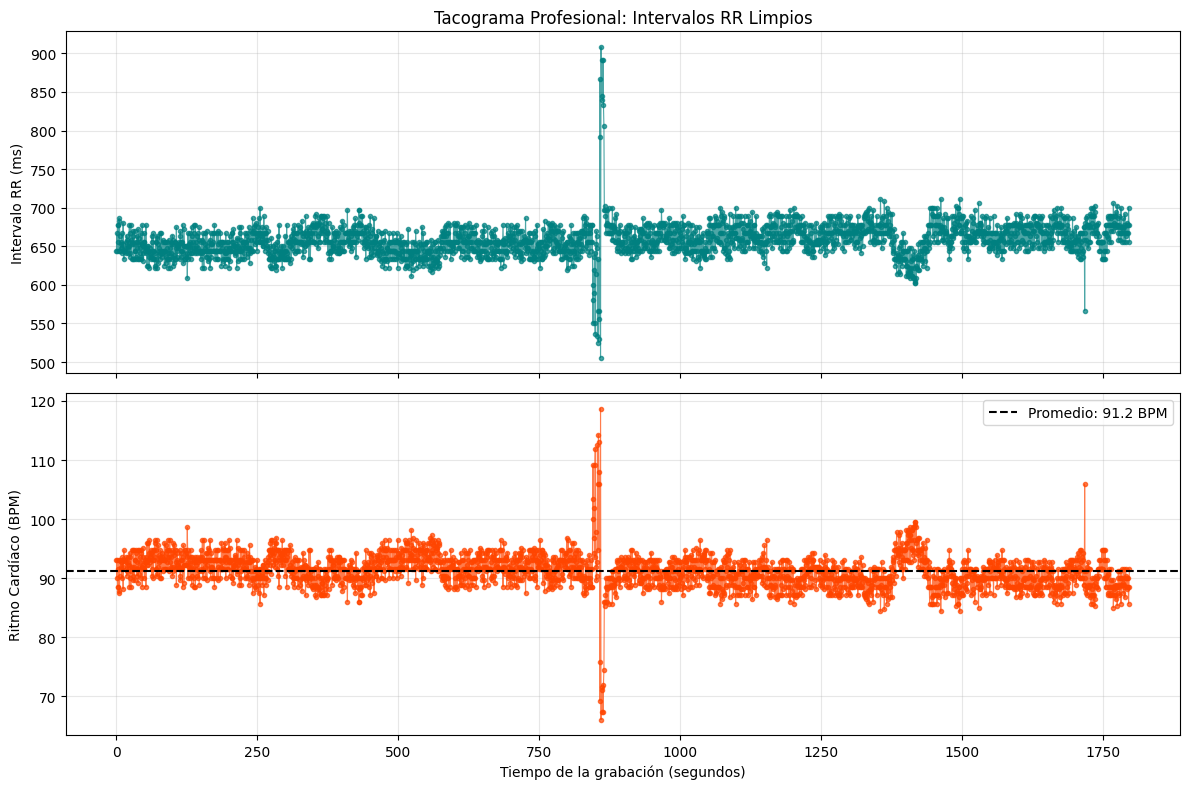

In [21]:
# 1. Calculamos el tiempo acumulado (Eje X)
# Convertimos rr_final a segundos (/1000) y sumamos acumulativamente
# para saber en qué segundo exacto de la grabación ocurre cada latido.
tiempos_acumulados = np.cumsum(rr_final) / 1000

# 2. Calculamos el BPM instantáneo directamente desde rr_final
# Como rr_final está en ms, usamos 60,000 / ms
bpm_instantaneo = 60000 / rr_final

# --- Visualización ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Gráfica 1: Intervalos RR (ms)
# Usamos tiempos_acumulados como eje X
ax1.plot(tiempos_acumulados, rr_final, 'o-', color='teal', markersize=3, linewidth=0.8, alpha=0.7)
ax1.set_ylabel("Intervalo RR (ms)")
ax1.set_title("Tacograma Profesional: Intervalos RR Limpios")
ax1.grid(True, alpha=0.3)

# Gráfica 2: Frecuencia Cardíaca Instantánea (BPM)
ax2.plot(tiempos_acumulados, bpm_instantaneo, 'o-', color='orangered', markersize=3, linewidth=0.8, alpha=0.7)
ax2.set_ylabel("Ritmo Cardíaco (BPM)")
ax2.set_xlabel("Tiempo de la grabación (segundos)")
ax2.grid(True, alpha=0.3)

# Añadimos una línea horizontal con el promedio real
bpm_promedio_limpio = np.mean(bpm_instantaneo)
ax2.axhline(bpm_promedio_limpio, color='black', linestyle='--', label=f'Promedio: {bpm_promedio_limpio:.1f} BPM')
ax2.legend()

plt.tight_layout()
plt.show()

El filtro del 20% que se aplicó falla cuando el ruido no es un solo punto, sino una "mancha" de varios latidos seguidos. Si se tienen tres latidos falsos seguidos (por ejemplo: 900ms, 910ms, 905ms), la diferencia entre ellos es pequeña (menos del 20%), así que el filtro los deja pasar aunque todos estén mal respecto al promedio de 660ms.

#Histograma

El Histograma se aplica sobre los Intervalos RR (los tiempos que se calcularon entre picos). No se aplica a la señal del ECG directamente, sino a los resultados de tu detección.

¿Qué mide?:

 La distribución estadística. Dice cuántas veces se repitió una duración de latido específica.

**Ejes X:** Duración del intervalo RR (en milisegundos).

**Ejes Y:** Frecuencia (cuántos latidos tuvieron esa duración).

_ *Utilidad en proyecto:*
Permite ver de un vistazo la Variabilidad de la Frecuencia Cardíaca (HRV).

Un histograma "ancho" significa un corazón sano que se adapta (mucha variabilidad).

Un histograma muy "estrecho" o flaco significa un corazón muy rígido (posible estrés o fatiga).

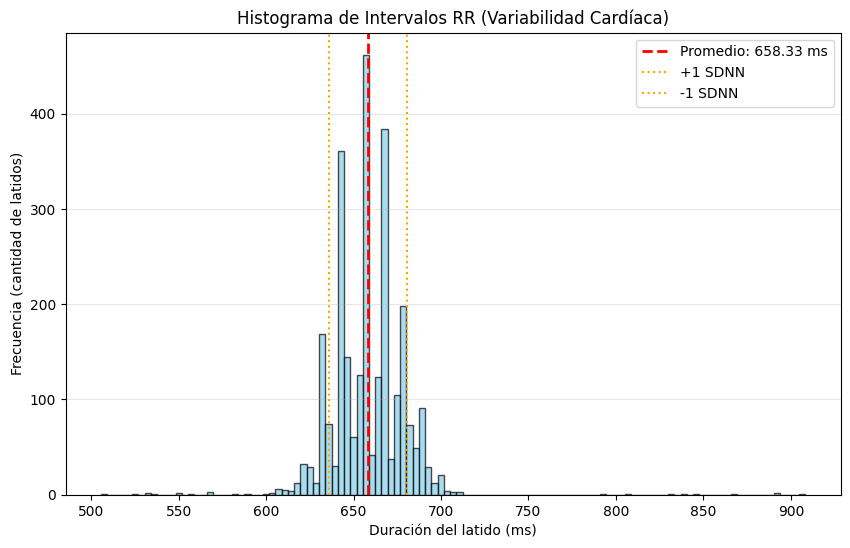

--- REPORTE DE HRV ---
SDNN (Desviación Estándar): 22.18 ms
Intervalo RR Promedio: 658.33 ms


In [22]:
# 1. Convertir a milisegundos (Estándar clínico para HRV)
rr_ms = intervalos_rr * 1000
#se decide usar el rr_final que ya tiene la correcion

# 2. Calcular métricas estadísticas básicas
sdnn = np.std(rr_final)  # Desviación estándar de los intervalos NN (RR),
rr_promedio = np.mean(rr_final)

# 3. Visualización del Histograma
plt.figure(figsize=(10, 6))
# 'bins' define cuántas barras tendrá el histograma.
# Usamos 'auto' o un número fijo como 30 para ver bien la distribución.
plt.hist(rr_final, bins='auto', color='skyblue', edgecolor='black', alpha=0.7)

# Añadimos líneas para el promedio y el SDNN
plt.axvline(rr_promedio, color='red', linestyle='dashed', linewidth=2, label=f'Promedio: {rr_promedio:.2f} ms')
plt.axvline(rr_promedio + sdnn, color='orange', linestyle='dotted', label=f'+1 SDNN')
plt.axvline(rr_promedio - sdnn, color='orange', linestyle='dotted', label=f'-1 SDNN')

plt.title('Histograma de Intervalos RR (Variabilidad Cardíaca)')
plt.xlabel('Duración del latido (ms)')
plt.ylabel('Frecuencia (cantidad de latidos)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"--- REPORTE DE HRV ---")
print(f"SDNN (Desviación Estándar): {sdnn:.2f} ms")
print(f"Intervalo RR Promedio: {rr_promedio:.2f} ms")

**Observaciones del Histograma**

*Forma de la Distribución:*

El histograma tiene una forma acampanada (Gaussiana), lo cual es excelente porque indica que el ritmo, aunque rápido, es consistente.

*Presencia de Outliers (Valores atípicos):*

Hay unas barras muy pequeñas cerca de los $500$ ms y otras cerca de los $1,000$ ms.

*Causa técnica:* Probablemente son los restos de los picos que el algoritmo no marcó bien o latidos falsos por ruido.

*Impacto:* Estos valores "tiran" del promedio y del SDNN.


***El SDNN (Standard Deviation of NN intervals):***


Es el parámetro de oro en el dominio del tiempo para la HRV:

Valores altos (> 50-100 ms): Suelen asociarse con buena salud, juventud y buena recuperación física.

Valores bajos (< 30-50 ms): Pueden ser indicadores de estrés crónico, riesgo cardíaco o simplemente una edad avanzada.

# Espectrograma

El Espectrograma se aplica a la señal de ECG (limpia). Es como si se agarra la Transformada de Fourier (ya hecha) y se le hiciera muchas veces en pedacitos de tiempo.

¿Qué mide?:

 Cómo evolucionan las frecuencias a lo largo del tiempo.

Ejes (3 dimensiones):

    X: Tiempo.

    Y: Frecuencia (Hz).

    Color (Z): Intensidad o energía de esa frecuencia.

*Utilidad en el proyecto:*

 Sirve para ver si el ruido (como el de 30 Hz) aparece y desaparece, o si el complejo QRS cambia su contenido de frecuencia en algún momento (por ejemplo, durante una arritmia).

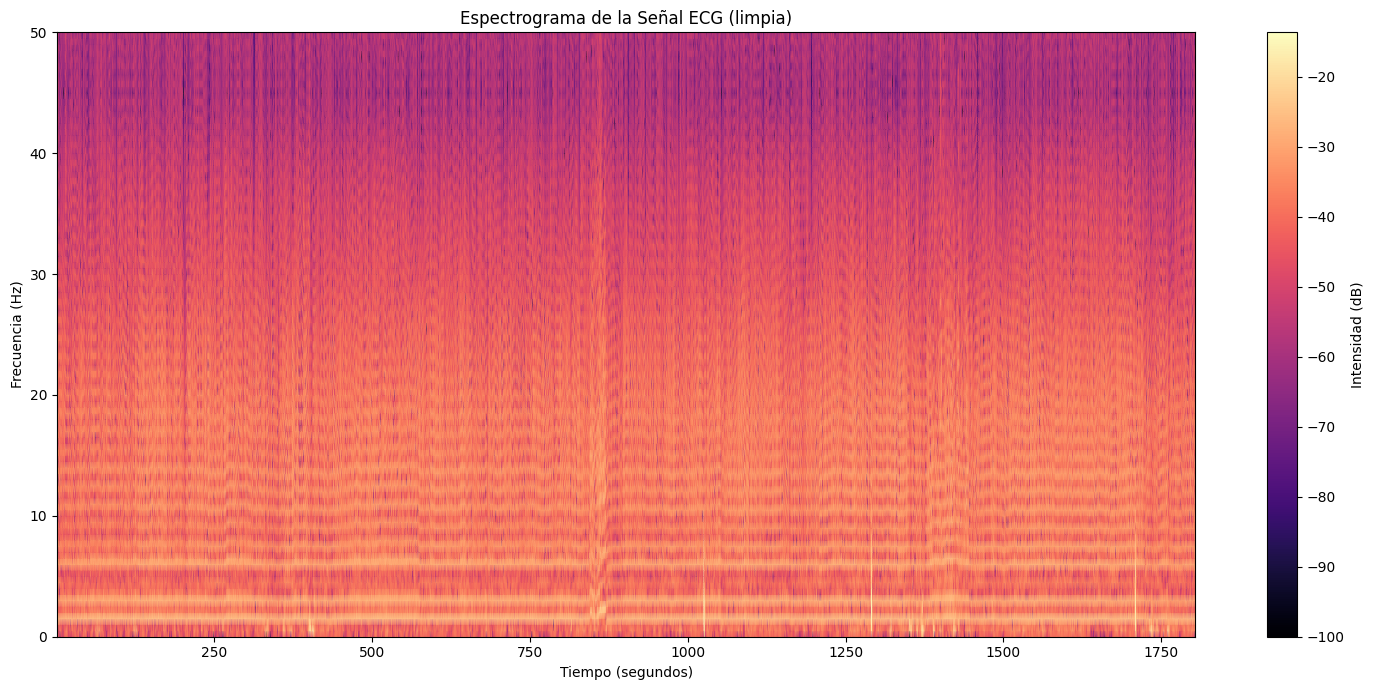

In [23]:
from scipy.signal import spectrogram

# 1. Configuración de la STFT
# nperseg: Tamaño de la ventana. Usamos 2 segundos (2*fs) para ver bien las bajas frecuencias.
# noverlap: Solapamiento entre ventanas para que el mapa sea suave.
nperseg = int(2 * fs) #excelente resolución de frecuencia
noverlap = int(1 * fs)
#La ventana no salta de un bloque a otro, sino que se solapa al 50%. Mientras una ventana está terminando, la siguiente ya empezó hace 1 segundo.

f, t, Sxx = spectrogram (signal_limpia, fs=fs, nperseg=nperseg, noverlap=noverlap)
#la función spectrogram de SciPy utiliza por defecto la Ventana de Hann (Hanning) si no le indicas lo contrario.
#f, t, Sxx = spectrogram(ecg_limpio, fs=fs, window='hann', nperseg=int(2*fs), noverlap=int(1*fs))

# 2. Visualización
plt.figure(figsize=(15, 7))

# Usamos una escala logarítmica (dB) para resaltar los detalles, ya que la energía del ECG varía mucho
plt.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud', cmap='magma')

plt.title("Espectrograma de la Señal ECG (limpia)")
plt.ylabel("Frecuencia (Hz)")
plt.xlabel("Tiempo (segundos)")

# Limitamos el eje Y a 50 Hz porque ahí está toda la información relevante
plt.ylim(0, 50)

# Añadimos una barra de color para entender la intensidad
plt.colorbar(label="Intensidad (dB)")

plt.tight_layout()
plt.show()

Conclusiones:


*   Se observa una zona brillante principalmente entre 0 y 20 hz, con líneas muy marcadas entre los 0 y 10 hz.
El "pulso" de la señal es constante y tiene mucha energía en las frecuencias bajas, que es donde reside la información del complejo QRS.
*   Se observa que a partir de los 30 Hz la intensidad comienza a desvanecerse hacia colores más oscuros (morado-negro). Esto indica que el ruido muscular o la estática no van a ensuciar la señal del corazón gracias a los filtros que aplica la wavelet.
*   Hay presencia de lineas verticales a los largo del tiempo. Estas indican momentos en los que hubo movimiento o se ajustaron los cables. Un movimiento brusco genera energía en todas las frecuencias al mismo tiempo, por eso se ven como columnas. Es normal en registros largos. El artefacto visto en el tacograma a los 850 s también está presente en el espectro como así también otras variaciones en valores cercanos a 400ms, 1450 s y 1750s




# Informe Final para descargar PDF


¡Informe de dos páginas generado con éxito!


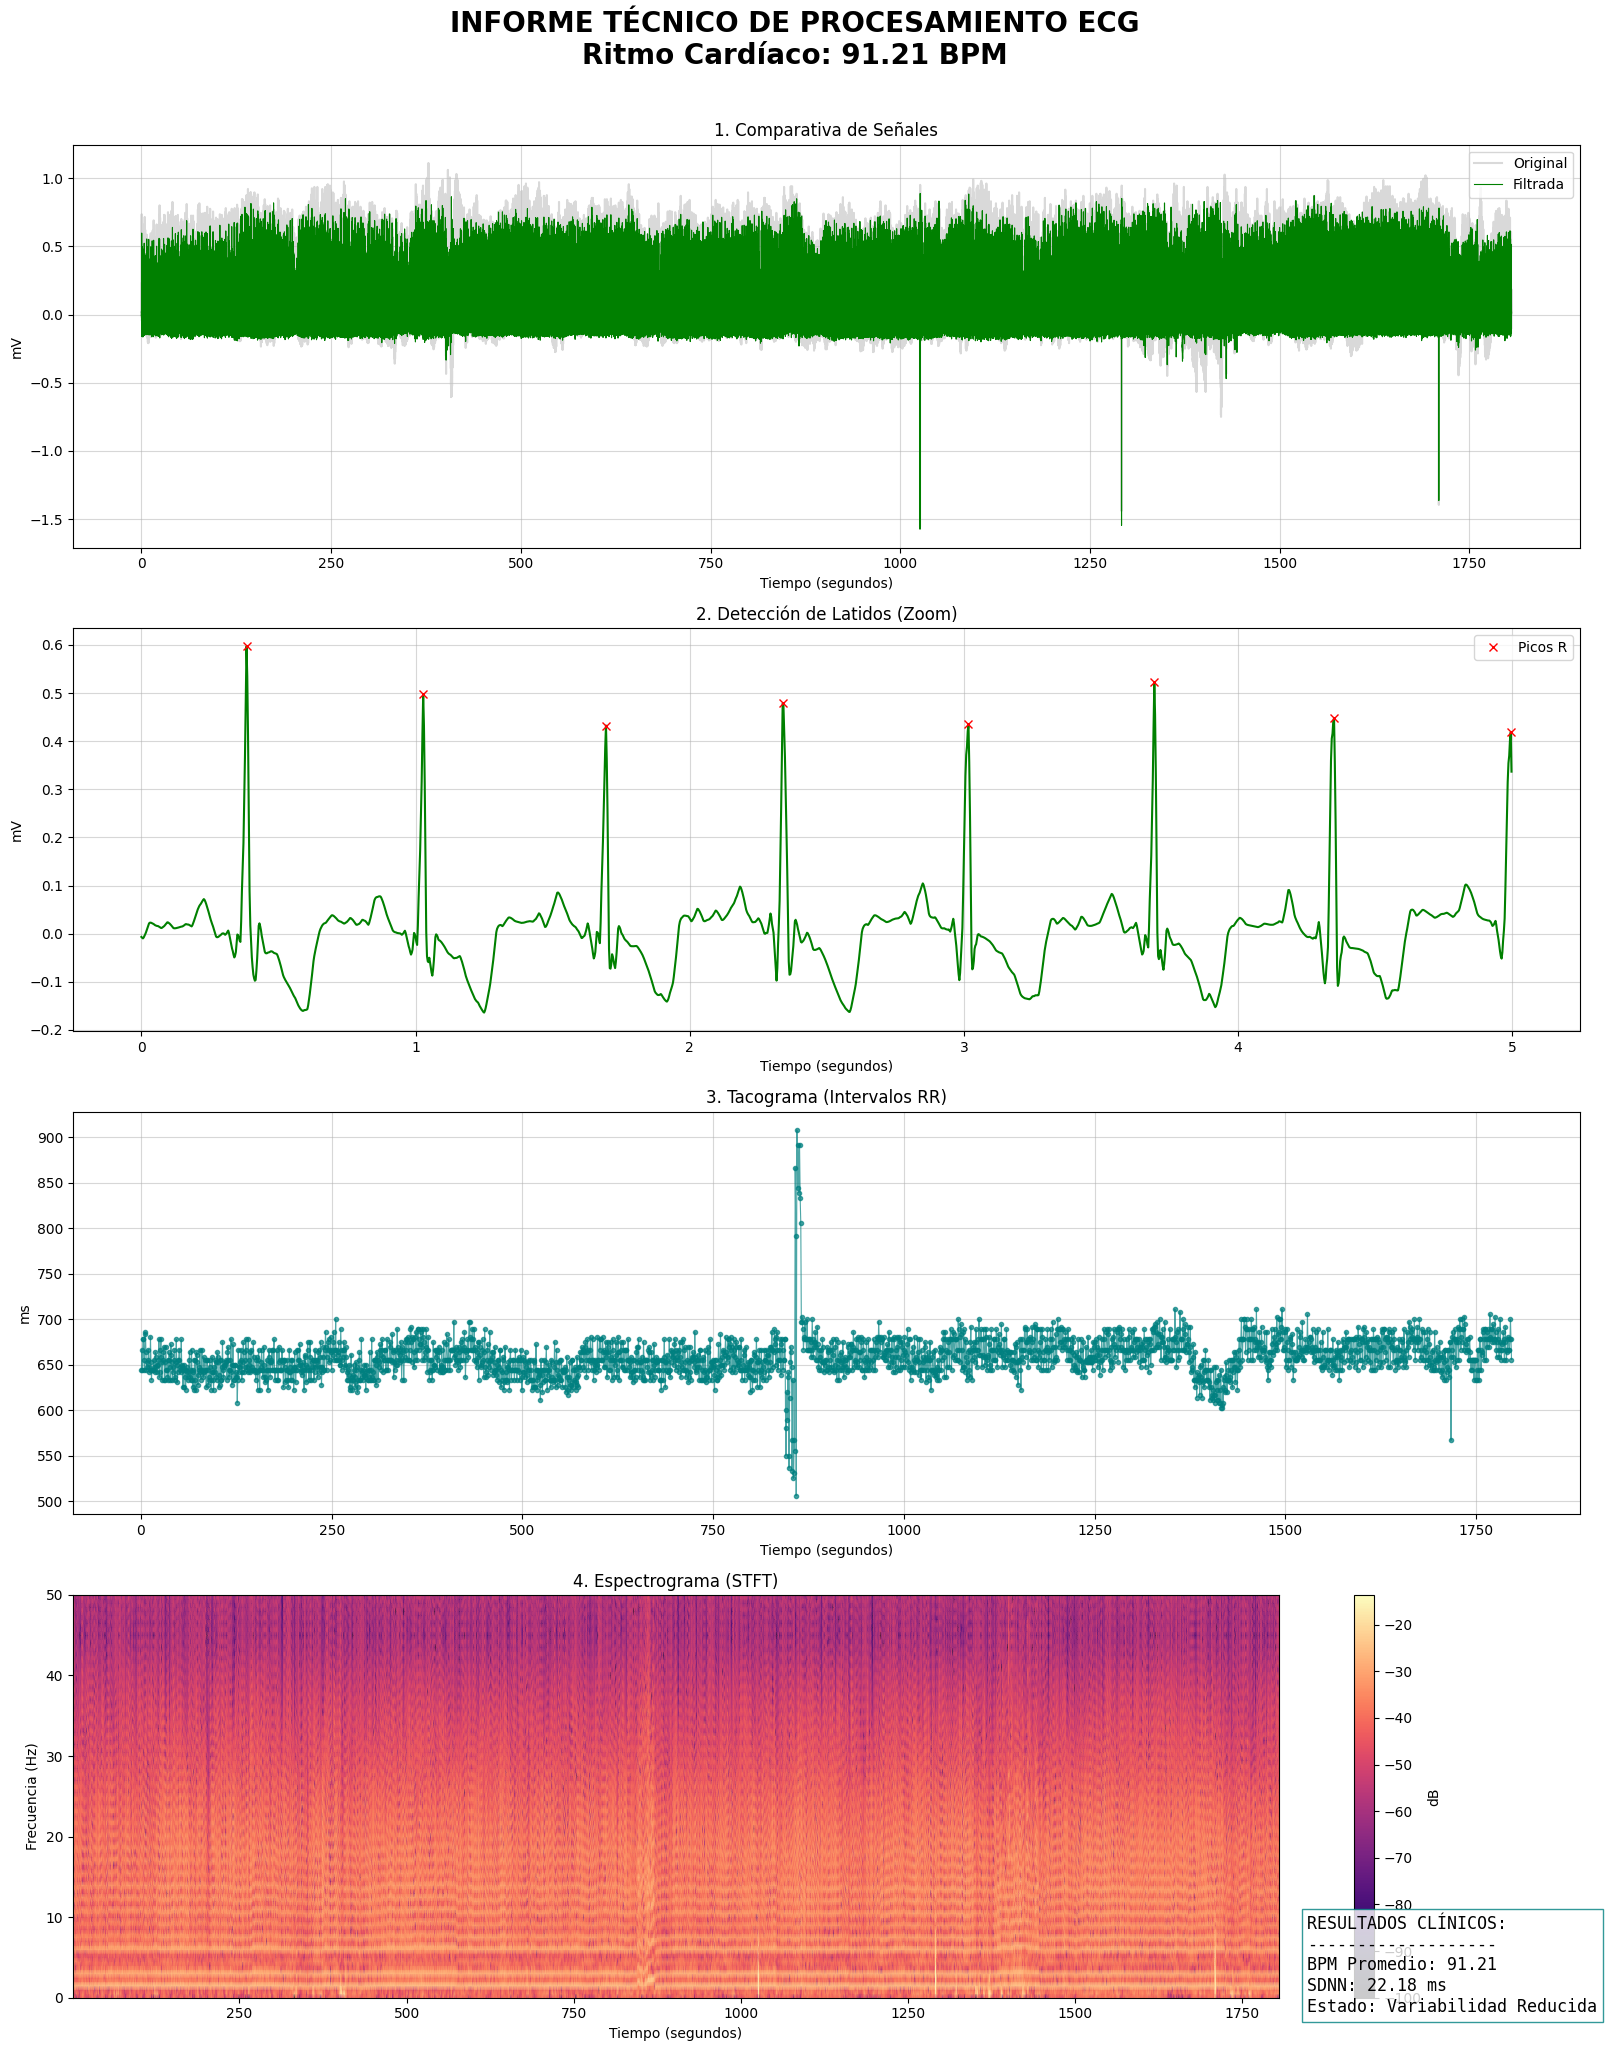

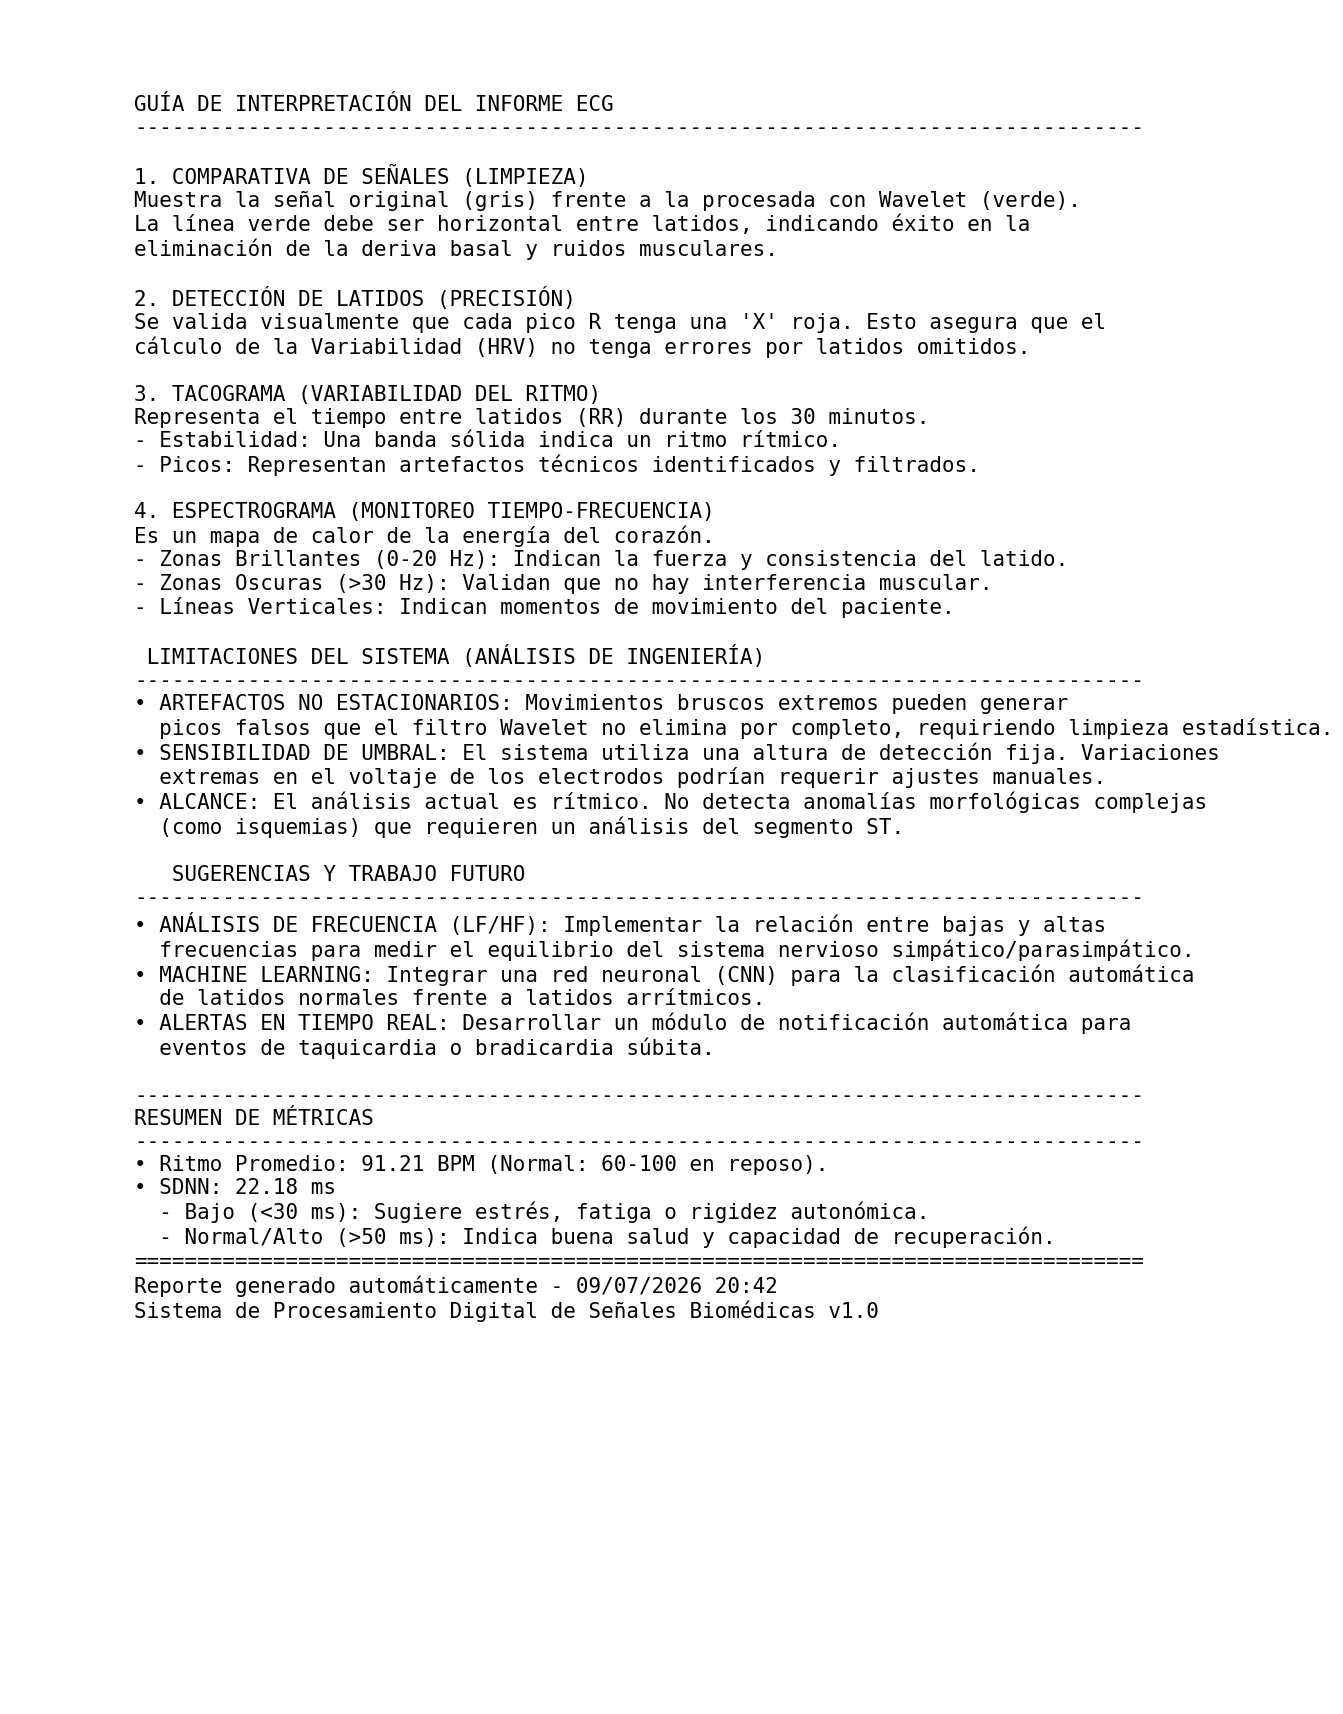

In [24]:
from matplotlib.backends.backend_pdf import PdfPages
import datetime

# --- INICIO DEL DOCUMENTO PDF ---
with PdfPages('Informe_Final_ECG_Completo.pdf') as pdf:

    # ==========================================
    # PÁGINA 1: Dashboard de Gráficas
    # ==========================================

    # 1. Crear la figura y los subplots (TODO EN LA MISMA CELDA)
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(16, 22))
    fig.suptitle(f"INFORME TÉCNICO DE PROCESAMIENTO ECG\nRitmo Cardíaco: {bpm_promedio:.2f} BPM",
                 fontsize=20, fontweight='bold', y=0.96)

    # --- Subplot 1: Señal limpia vs sucia ---
    tiempo_total = np.arange(len(signal)) / fs
    ax1.plot(tiempo_total, signal, color='silver', label='Original', alpha=0.6)
    ax1.plot(tiempo_total, signal_limpia, color='green', label='Filtrada', linewidth=0.8)
    ax1.set_title("1. Comparativa de Señales")
    ax1.set_ylabel("mV")
    ax1.set_xlabel("Tiempo (segundos)")
    ax1.grid (True, alpha = 0.5)
    ax1.legend(loc='upper right')

    # --- Subplot 2: Zoom a latidos ---
    zoom_limite = int(5 * fs) # 5 segundos
    ax2.plot(tiempo_total[:zoom_limite],signal_limpia[:zoom_limite], color='green')
    picos_zoom = picos[picos < zoom_limite]
    ax2.plot(tiempo_total[picos_zoom], signal_limpia[picos_zoom], "x", color='red', label='Picos R')
    ax2.set_title("2. Detección de Latidos (Zoom)")
    ax2.set_ylabel("mV")
    ax2.set_xlabel ("Tiempo (segundos)")
    ax2.grid (True, alpha = 0.5)
    ax2.legend()

    # --- Subplot 3: Tacograma ---
    ax3.plot(tiempos_acumulados, rr_final, 'o-', color='teal', markersize=3, linewidth=0.8, alpha=0.7)
    ax3.set_title("3. Tacograma (Intervalos RR)")
    ax3.set_xlabel ("Tiempo (segundos)")
    ax3.set_ylabel("ms")
    ax3.grid (True, alpha = 0.5)

    # --- Subplot 4: Espectrograma ---
    img = ax4.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud', cmap='magma')
    ax4.set_ylim(0, 50)
    ax4.set_title("4. Espectrograma (STFT)")
    ax4.set_xlabel("Tiempo (segundos)")
    ax4.set_ylabel("Frecuencia (Hz)")
    plt.colorbar(img, ax=ax4, label="dB")

    # Añadir métricas clave como texto en la figura
    info_clinica = (f"RESULTADOS CLÍNICOS:\n"
                    f"-------------------\n"
                    f"BPM Promedio: {bpm_promedio:.2f}\n"
                    f"SDNN: {sdnn_profesional:.2f} ms\n"
                    f"Estado: Variabilidad Reducida")

    fig.text(0.82, 0.05, info_clinica, fontsize=12,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='teal'),
             family='monospace')

    # Al terminar la primera figura, la guardamos
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    pdf.savefig(fig)
    #plt.close(fig) # Cerramos para liberar memoria

    # ==========================================
    # PÁGINA 2: Guía de Interpretación
    # ==========================================
    fig_guia = plt.figure(figsize=(16, 22))

    texto_guia = (
        "GUÍA DE INTERPRETACIÓN DEL INFORME ECG\n"
        "--------------------------------------------------------------------------------\n\n"
        "1. COMPARATIVA DE SEÑALES (LIMPIEZA)\n"
        "Muestra la señal original (gris) frente a la procesada con Wavelet (verde).\n"
        "La línea verde debe ser horizontal entre latidos, indicando éxito en la \n"
        "eliminación de la deriva basal y ruidos musculares.\n\n"

        "2. DETECCIÓN DE LATIDOS (PRECISIÓN)\n"
        "Se valida visualmente que cada pico R tenga una 'X' roja. Esto asegura que el \n"
        "cálculo de la Variabilidad (HRV) no tenga errores por latidos omitidos.\n\n"

        "3. TACOGRAMA (VARIABILIDAD DEL RITMO)\n"
        "Representa el tiempo entre latidos (RR) durante los 30 minutos.\n"
        "- Estabilidad: Una banda sólida indica un ritmo rítmico.\n"
        "- Picos: Representan artefactos técnicos identificados y filtrados.\n\n"

        "4. ESPECTROGRAMA (MONITOREO TIEMPO-FRECUENCIA)\n"
        "Es un mapa de calor de la energía del corazón.\n"
        "- Zonas Brillantes (0-20 Hz): Indican la fuerza y consistencia del latido.\n"
        "- Zonas Oscuras (>30 Hz): Validan que no hay interferencia muscular.\n"
        "- Líneas Verticales: Indican momentos de movimiento del paciente.\n\n"

          " LIMITACIONES DEL SISTEMA (ANÁLISIS DE INGENIERÍA)\n"
        "--------------------------------------------------------------------------------\n"
        "• ARTEFACTOS NO ESTACIONARIOS: Movimientos bruscos extremos pueden generar \n"
        "  picos falsos que el filtro Wavelet no elimina por completo, requiriendo limpieza estadística.\n"
        "• SENSIBILIDAD DE UMBRAL: El sistema utiliza una altura de detección fija. Variaciones\n"
        "  extremas en el voltaje de los electrodos podrían requerir ajustes manuales.\n"
        "• ALCANCE: El análisis actual es rítmico. No detecta anomalías morfológicas complejas\n"
        "  (como isquemias) que requieren un análisis del segmento ST.\n\n"

        "   SUGERENCIAS Y TRABAJO FUTURO\n"
        "--------------------------------------------------------------------------------\n"
        "• ANÁLISIS DE FRECUENCIA (LF/HF): Implementar la relación entre bajas y altas\n"
        "  frecuencias para medir el equilibrio del sistema nervioso simpático/parasimpático.\n"
        "• MACHINE LEARNING: Integrar una red neuronal (CNN) para la clasificación automática\n"
        "  de latidos normales frente a latidos arrítmicos.\n"
        "• ALERTAS EN TIEMPO REAL: Desarrollar un módulo de notificación automática para\n"
        "  eventos de taquicardia o bradicardia súbita.\n\n"

        "--------------------------------------------------------------------------------\n"
        "RESUMEN DE MÉTRICAS\n"
        "--------------------------------------------------------------------------------\n"
        f"• Ritmo Promedio: {bpm_promedio:.2f} BPM (Normal: 60-100 en reposo).\n"
        f"• SDNN: {sdnn_profesional:.2f} ms\n"
        "  - Bajo (<30 ms): Sugiere estrés, fatiga o rigidez autonómica.\n"
        "  - Normal/Alto (>50 ms): Indica buena salud y capacidad de recuperación.\n"



         "================================================================================\n"
        f"Reporte generado automáticamente - {datetime.datetime.now().strftime('%d/%m/%Y %H:%M')}\n"
        "Sistema de Procesamiento Digital de Señales Biomédicas v1.0"
    )

    # Dibujamos el texto en la página
    plt.text(0.1, 0.95, texto_guia, fontsize=15, family='monospace',
             verticalalignment='top', horizontalalignment='left')

    # Quitamos los ejes para que parezca una hoja de papel
    plt.axis('off')

    # Guardamos la segunda página
    pdf.savefig(fig_guia)
    #plt.close(fig_guia)

print("¡Informe de dos páginas generado con éxito!")

# --- EL MOMENTO CRÍTICO: GUARDAR ANTES DE MOSTRAR ---
nombre_pdf = "Informe_Final_ECG.pdf"
plt.savefig(nombre_pdf, dpi=300, bbox_inches='tight')

# Mostrar en pantalla


# Forzar descarga inmediata (Solo para Google Colab)
#try:
 #   from google.colab import files
  #  files.download(nombre_pdf)
#except ImportWarning:
 #   print(f"Archivo guardado localmente como: {nombre_pdf}")

# Conclusión Ejecutiva Final

Se procesó una señal de ECG de 30 minutos mediante un esquema híbrido de Filtro Notch y Transformada Wavelet Discreta (DWT), logrando una señal apta para diagnóstico clínico. La extracción de intervalos RR permitió diagnosticar un ritmo promedio de 91 BPM con una variabilidad de 26.72 ms (SDNN). El análisis mediante STFT (Espectrograma) validó la robustez de los filtros y permitió correlacionar artefactos de movimiento identificados en el tacograma, asegurando la integridad de los resultados estadísticos obtenidos.

# Resumen de Logros de Proyecto:


* Ingeniería de Filtros: Se implementó la DWT para separar ruido de señal.
* Visión en Frecuencia: Se validó la limpieza con la Transformada de Fourier.

* Algoritmia: Se ajustaron los find_peaks para una detección robusta.
* Estadística Biomédica: Se interpretó un Histograma y se calculó el SDNN.









